# MLP para classificação do CIFAR-10

Rede Neural MLP treinada no CIFAR-10 (convertido para escala de cinza) em 4 configurações:

| Config | Dropout | Early Stop |
|---|---|---|
| A | Não | Não |
| B | Não | Sim |
| C | Sim | Não |
| D | Sim | Sim |

Cada configuração é executada **3 vezes** (seeds diferentes), registrando a acurácia de **treino** e de **teste**.

**Referência dos hiperparâmetros:** N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, R. Salakhutdinov.
*Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. Journal of Machine Learning Research, 15(56):1929–1958, 2014.

## 1. Configuração

In [1]:
import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from keras.constraints import MaxNorm
from keras.datasets import cifar10

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1791233886.087368  297920 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791233886.127618  297920 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791233887.203708  297920 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | Keras: 3.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Modo rápido para testar o pipeline de ponta a ponta (poucas épocas, subconjunto dos dados).
# Use False para rodar os experimentos finais.
QUICK_TEST = False

# --- Hiperparâmetros baseados em Srivastava et al. (2014), experimentos com MLP ---
HIDDEN_LAYERS = 3          # 3 camadas ocultas
HIDDEN_UNITS = 1024        # 1024 neurônios por camada, ReLU
DROPOUT_INPUT = 0.2        # taxa de dropout na entrada (p de retenção = 0.8 no artigo)
DROPOUT_HIDDEN = 0.5       # taxa de dropout nas ocultas (p de retenção = 0.5 no artigo)
MAX_NORM = 3.0             # restrição max-norm usada junto com dropout no artigo (c entre 3 e 4)
LEARNING_RATE = 0.01       # SGD
MOMENTUM = 0.95            # momentum usado no artigo

# TODO: confirmar no Apêndice B do artigo e citar na apresentação.
EPOCHS = 100
BATCH_SIZE = 100

# --- Early stopping / validação ---
VALIDATION_SPLIT = 0.1     # usado em todas as configs, para comparação justa
PATIENCE = 10

# --- Experimento ---
N_RUNS = 3
SEEDS = [0, 1, 2]
CONFIGS = [
    {"nome": "A: sem dropout, sem early stop", "dropout": False, "early_stop": False},
    {"nome": "B: sem dropout, com early stop", "dropout": False, "early_stop": True},
    {"nome": "C: com dropout, sem early stop", "dropout": True, "early_stop": False},
    {"nome": "D: com dropout, com early stop", "dropout": True, "early_stop": True},
]

RESULTS_DIR = "results_quick" if QUICK_TEST else "results"
if QUICK_TEST:
    EPOCHS = 2
    N_RUNS = 1
    SUBSET = 5000
else:
    SUBSET = None

os.makedirs(os.path.join(RESULTS_DIR, "histories"), exist_ok=True)

## 2. Dados

Conversão RGB → escala de cinza conforme o enunciado (Y = 0.299 R + 0.587 G + 0.114 B), achatamento para vetores de 1024 posições e normalização para [0, 1].

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

x_train_flat = (x_train_gray.reshape(-1, 32 * 32) / 255.0).astype("float32")
x_test_flat = (x_test_gray.reshape(-1, 32 * 32) / 255.0).astype("float32")
y_train = y_train.ravel()
y_test = y_test.ravel()

if SUBSET:
    x_train_flat, y_train = x_train_flat[:SUBSET], y_train[:SUBSET]
    x_test_flat, y_test = x_test_flat[:SUBSET // 5], y_test[:SUBSET // 5]

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

print("Treino:", x_train_flat.shape, "| Teste:", x_test_flat.shape)

Treino: (50000, 1024) | Teste: (10000, 1024)


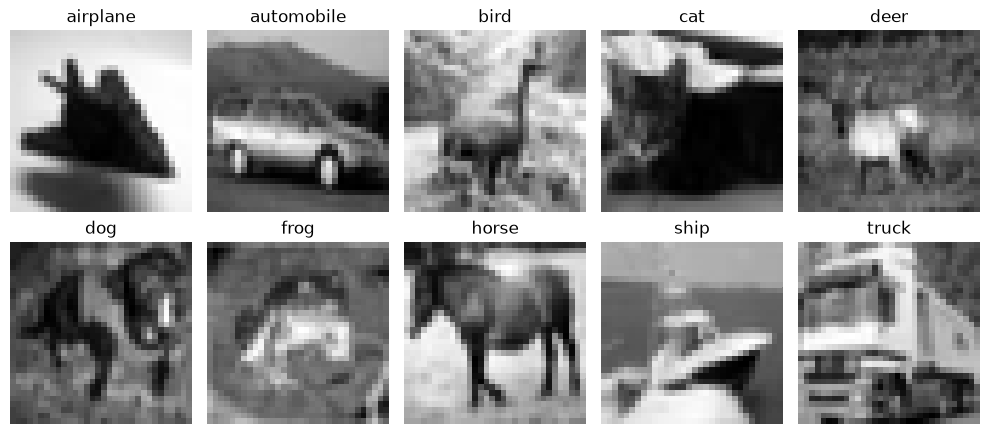

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train_flat[idx].reshape(32, 32), cmap="gray")
    ax.set_title(CLASSES[i])
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exemplos.png"), dpi=150)
plt.show()

## 3. Modelo

In [5]:
def build_mlp(use_dropout: bool) -> keras.Model:
    model = keras.Sequential([layers.Input(shape=(32 * 32,))])
    if use_dropout:
        model.add(layers.Dropout(DROPOUT_INPUT))
    for _ in range(HIDDEN_LAYERS):
        model.add(layers.Dense(
            HIDDEN_UNITS,
            activation="relu",
            kernel_constraint=MaxNorm(MAX_NORM) if use_dropout else None,
        ))
        if use_dropout:
            model.add(layers.Dropout(DROPOUT_HIDDEN))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=MOMENTUM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


build_mlp(use_dropout=True).summary()

I0000 00:00:1791233891.457112  297920 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3504 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,159,050 (12.05 MB)

 Trainable params: 3,159,050 (12.05 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Experimento

In [6]:
def run_experiment(config: dict, run: int, seed: int) -> dict:
    keras.utils.set_random_seed(seed)
    model = build_mlp(config["dropout"])

    callbacks = []
    if config["early_stop"]:
        callbacks.append(keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
        ))

    start = time.time()
    history = model.fit(
        x_train_flat, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks,
        verbose=2,
    )
    elapsed = time.time() - start

    _, acc_train = model.evaluate(x_train_flat, y_train, batch_size=1000, verbose=0)
    _, acc_test = model.evaluate(x_test_flat, y_test, batch_size=1000, verbose=0)

    return {
        "config": config["nome"],
        "dropout": config["dropout"],
        "early_stop": config["early_stop"],
        "run": run,
        "seed": seed,
        "acc_treino": acc_train,
        "acc_teste": acc_test,
        "epocas": len(history.history["loss"]),
        "tempo_s": elapsed,
        "history": history.history,
    }

## 5. Execução (4 configs × 3 runs)

Os resultados são salvos a cada treino em `results/resultados.csv`; se o notebook for interrompido, os runs já concluídos são pulados ao re-executar.

In [7]:
csv_path = os.path.join(RESULTS_DIR, "resultados.csv")
results = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()

for cfg_idx, config in enumerate(CONFIGS):
    for run in range(N_RUNS):
        done = (not results.empty and
                ((results["config"] == config["nome"]) & (results["run"] == run)).any())
        if done:
            print(f"Pulando (já executado): {config['nome']} | run {run}")
            continue

        print(f"\n=== {config['nome']} | run {run} (seed {SEEDS[run]}) ===")
        res = run_experiment(config, run, SEEDS[run])

        with open(os.path.join(RESULTS_DIR, "histories", f"cfg{cfg_idx}_run{run}.json"), "w") as f:
            json.dump(res.pop("history"), f)

        results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)
        results.to_csv(csv_path, index=False)
        print(f"acc_treino={res['acc_treino']:.4f} | acc_teste={res['acc_teste']:.4f} | "
              f"épocas={res['epocas']} | tempo={res['tempo_s']:.0f}s")


=== A: sem dropout, sem early stop | run 0 (seed 0) ===


Epoch 1/100


I0000 00:00:1791233892.691407  298243 service.cc:153] XLA service 0x7b7e18031670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791233892.691423  298243 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791233892.701076  298243 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791233892.765570  298243 cuda_dnn.cc:461] Loaded cuDNN version 92700
I0000 00:00:1791233892.769742  298243 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1006__.14


I0000 00:00:1791233893.506897  298337 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1791233893.604962  298326 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 824 bytes spill stores, 824 bytes spill loads



I0000 00:00:1791233894.272668  298330 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 684 bytes spill stores, 720 bytes spill loads



...

Epoch 99/100


450/450 - 1s - 2ms/step - accuracy: 0.3561 - loss: 1.7977 - val_accuracy: 0.3730 - val_loss: 1.7903


Epoch 100/100


450/450 - 1s - 2ms/step - accuracy: 0.3532 - loss: 1.8038 - val_accuracy: 0.3760 - val_loss: 1.8008


acc_treino=0.4133 | acc_teste=0.3887 | épocas=100 | tempo=103s


## 6. Resultados

In [8]:
results = pd.read_csv(csv_path)
results[["config", "run", "acc_treino", "acc_teste", "epocas", "tempo_s"]].round(4)

,config,run,acc_treino,acc_teste,epocas,tempo_s
0,"A: sem dropout, sem early stop",0,0.6079,0.3736,100,91.7121
1,"A: sem dropout, sem early stop",1,0.5709,0.3506,100,88.9872
2,"A: sem dropout, sem early stop",2,0.5843,0.3606,100,92.6783
3,"B: sem dropout, com early stop",0,0.4721,0.4140,21,20.9595
4,"B: sem dropout, com early stop",1,0.4936,0.4164,24,23.9333
5,"B: sem dropout, com early stop",2,0.4564,0.4048,21,20.1827
6,"C: com dropout, sem early stop",0,0.3954,0.3711,100,98.7534
7,"C: com dropout, sem early stop",1,0.3861,0.3580,100,97.6482
8,"C: com dropout, sem early stop",2,0.4038,0.3748,100,101.4337
9,"D: com dropout, com early stop",0,0.4094,0.3796,100,102.7873


In [9]:
summary = (results.groupby("config", sort=False)
           .agg(acc_treino_media=("acc_treino", "mean"),
                acc_treino_std=("acc_treino", "std"),
                acc_teste_media=("acc_teste", "mean"),
                acc_teste_std=("acc_teste", "std"),
                epocas_media=("epocas", "mean"),
                tempo_medio_s=("tempo_s", "mean")))
summary["gap_treino_teste"] = summary["acc_treino_media"] - summary["acc_teste_media"]
summary.to_csv(os.path.join(RESULTS_DIR, "resumo.csv"))
summary.round(4)

,acc_treino_media,acc_treino_std,acc_teste_media,acc_teste_std,epocas_media,tempo_medio_s,gap_treino_teste
config,,,,,,,
"A: sem dropout, sem early stop",0.5877,0.0188,0.3616,0.0115,100.0000,91.1259,0.2261
"B: sem dropout, com early stop",0.4740,0.0187,0.4117,0.0061,22.0000,21.6919,0.0623
"C: com dropout, sem early stop",0.3951,0.0088,0.3680,0.0088,100.0000,99.2784,0.0272
"D: com dropout, com early stop",0.4011,0.0178,0.3766,0.0139,90.6667,93.4683,0.0246


## 7. Gráficos

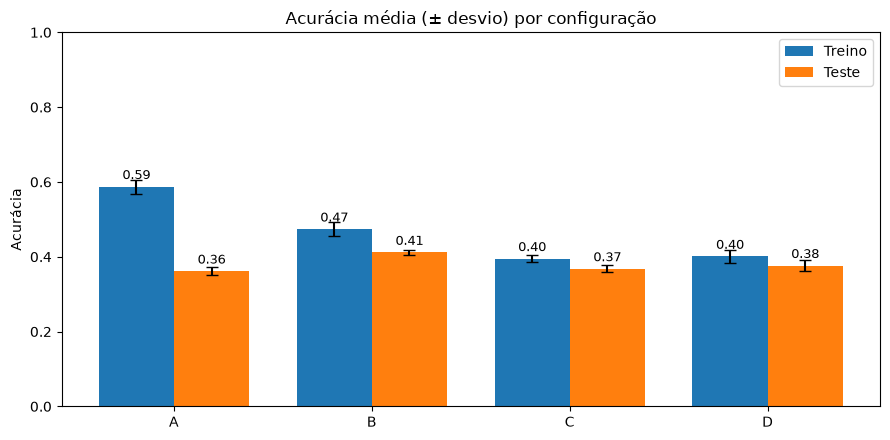

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(summary))
w = 0.38
ax.bar(x - w / 2, summary["acc_treino_media"], w, yerr=summary["acc_treino_std"].fillna(0),
       capsize=4, label="Treino")
ax.bar(x + w / 2, summary["acc_teste_media"], w, yerr=summary["acc_teste_std"].fillna(0),
       capsize=4, label="Teste")
ax.set_xticks(x, [c.split(":")[0] for c in summary.index])
ax.set_ylabel("Acurácia")
ax.set_ylim(0, 1)
ax.set_title("Acurácia média (± desvio) por configuração")
ax.legend()
for i, (tr, te) in enumerate(zip(summary["acc_treino_media"], summary["acc_teste_media"])):
    ax.text(i - w / 2, tr + 0.02, f"{tr:.2f}", ha="center", fontsize=9)
    ax.text(i + w / 2, te + 0.02, f"{te:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "barras_treino_teste.png"), dpi=150)
plt.show()

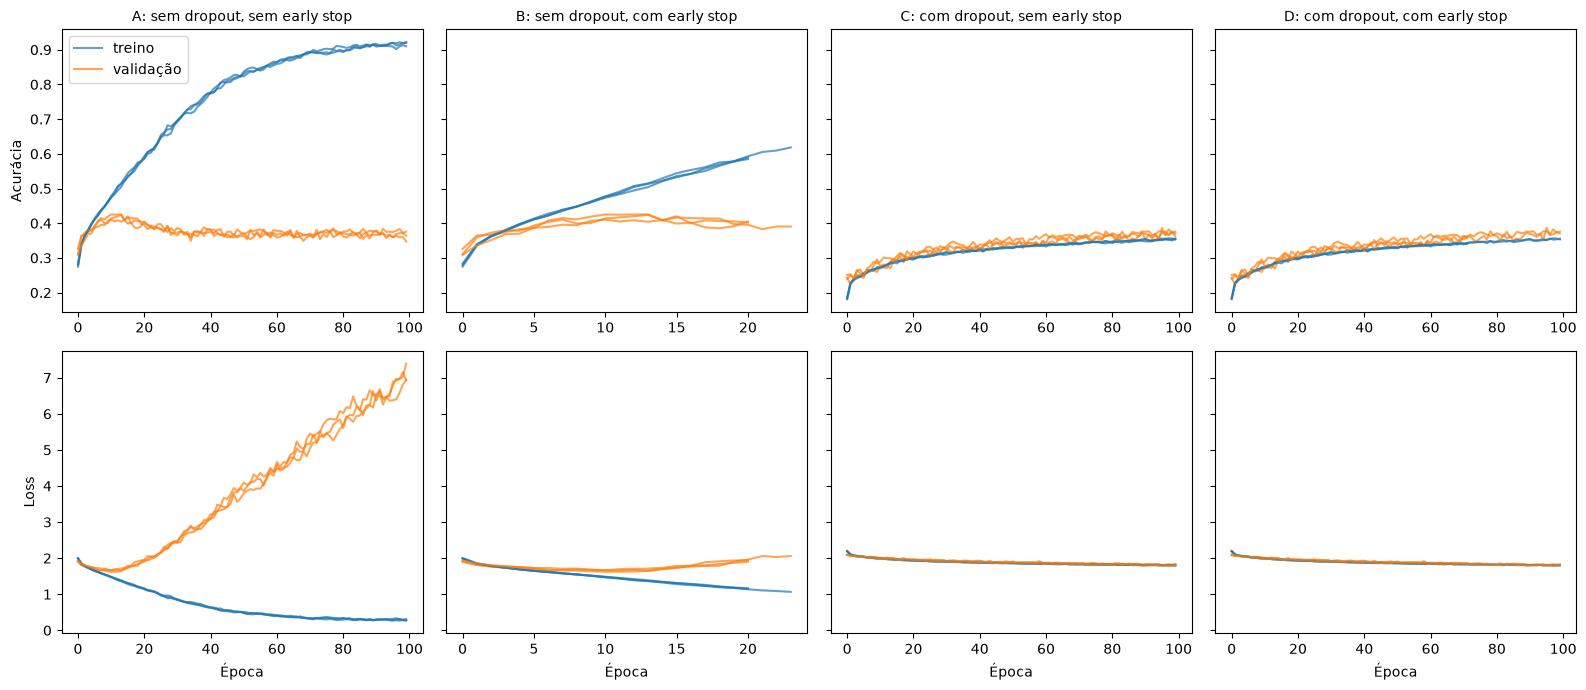

In [11]:
fig, axes = plt.subplots(2, len(CONFIGS), figsize=(4 * len(CONFIGS), 7), sharey="row")
for cfg_idx, config in enumerate(CONFIGS):
    for run in range(N_RUNS):
        path = os.path.join(RESULTS_DIR, "histories", f"cfg{cfg_idx}_run{run}.json")
        if not os.path.exists(path):
            continue
        with open(path) as f:
            h = json.load(f)
        axes[0, cfg_idx].plot(h["accuracy"], color="C0", alpha=0.7, label="treino" if run == 0 else None)
        axes[0, cfg_idx].plot(h["val_accuracy"], color="C1", alpha=0.7, label="validação" if run == 0 else None)
        axes[1, cfg_idx].plot(h["loss"], color="C0", alpha=0.7)
        axes[1, cfg_idx].plot(h["val_loss"], color="C1", alpha=0.7)
    axes[0, cfg_idx].set_title(config["nome"], fontsize=10)
    axes[1, cfg_idx].set_xlabel("Época")
axes[0, 0].set_ylabel("Acurácia")
axes[1, 0].set_ylabel("Loss")
axes[0, 0].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "curvas_treino.png"), dpi=150)
plt.show()

## 8. Conclusão (200–250 palavras)

> **Rascunho — reescrever com os números finais.** Pontos a abordar:
>
> - Acurácia de teste obtida por cada configuração (média ± desvio das 3 execuções) e qual foi a melhor.
> - **Gap treino × teste**: sem dropout e sem early stop a MLP tende a decorar o treino (overfitting) — o gap mostra isso.
> - **Efeito do dropout**: reduz o gap e, em geral, melhora a generalização, ao custo de convergência mais lenta.
> - **Efeito do early stopping**: interrompe o treino quando a validação piora, economizando épocas/tempo e evitando o overfitting tardio.
> - **Combinação dropout + early stop**: se foi a melhor ou se os efeitos se sobrepõem.
> - **Limitações**: MLP ignora a estrutura espacial da imagem (sem convolução) e a conversão para cinza descarta informação de cor — por isso a acurácia fica bem abaixo de CNNs.
> - Variância entre as 3 execuções (estabilidade dos resultados).